# 11. Lima

The third department, and the one that closes the set. [Arequipa](09_arequipa_dem.ipynb)
is high plateau, [Ancash](10_ancash_dem.ipynb) is the Cordillera Blanca, and Lima is the
coastal contrast — desert shelf rising to the western Andean flank, with the Cordillera
Huayhuash in its north-east corner.

Three regions, one question, every transferable criterion held fixed. This notebook is
mostly about what the **three-way** comparison says, because a difference between two
regions can be a coincidence and a trend across three is harder to dismiss.

In [1]:
import glob
import json
import os

import numpy as np

from oroscope import site_searcher as ss

## One dataset for all three

The Lima DEM used to be AW3D30 while Arequipa and Ancash were SRTMGL1. That would have
put a **dataset difference inside every comparison**, indistinguishable from a difference
in the ground, so Lima was re-downloaded as SRTMGL1 at the same 1 arc-second resolution.

```bash
export OPENTOPOGRAPHY_API_KEY=...
cd src && oroscope-fetch-dem --region lima
python -m oroscope.fetch_roads --dem ../input/dem/lima_SRTMGL1.tif --places

python tools/run_full_dem.py --region lima --dry-run
python tools/run_full_dem.py --region lima --max-memory-gb 6.0
```

In [2]:
STORES = {name: os.path.abspath(os.path.join("..", "results", f"{name}_full"))
          for name in ("arequipa", "ancash", "lima")}


def load(region, label):
    path = os.path.join(STORES[region], f"{label}_results.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        return json.load(f)


runs = {r: {e: load(r, e) for e in ("grand", "tambo")} for r in STORES}
for r, table in runs.items():
    got = [e for e, v in table.items() if v]
    print(f"{r:<10} {', '.join(got) if got else 'NOT IN THE STORE YET'}")

arequipa   grand, tambo
ancash     grand, tambo
lima       grand, tambo


## The configurations, diffed

Same check as the Ancash notebook, extended to three. Anything that differs is either
bookkeeping or is called out.

In [3]:
def settings(path):
    with open(path) as f:
        return {k: v for k, v in json.load(f).items() if not k.startswith("_")}


for experiment in ("grand", "tambo"):
    base = settings(os.path.join("..", "config", f"{experiment}_arequipa_full.json"))
    print(f"{experiment.upper()}, against arequipa:")
    for region in ("ancash", "lima"):
        other = settings(os.path.join("..", "config",
                                      f"{experiment}_{region}_full.json"))
        differ = [k for k in sorted(set(base) | set(other))
                  if base.get(k) != other.get(k)]
        bookkeeping = {"dem_path", "region_name"}
        real = [k for k in differ if k not in bookkeeping]
        print(f"    {region:<9} {len(differ)} differ "
              f"({len(differ) - len(real)} bookkeeping)"
              + (f" -> {real}" if real else ""))

GRAND, against arequipa:
    ancash    3 differ (2 bookkeeping) -> ['rfi_zones']
    lima      3 differ (2 bookkeeping) -> ['rfi_zones']
TAMBO, against arequipa:
    ancash    2 differ (2 bookkeeping)
    lima      2 differ (2 bookkeeping)


`rfi_zones` is the only real difference, and it is Arequipa that is the odd one
out: it excludes five hand-curated circles around its own towns, and neither Ancash nor
Lima has an equivalent list. Holding both at `none` keeps *those two* exactly comparable
and leaves one stated caveat against Arequipa — its zones cover ~3,500 km² of a
~120,000 km² box, so about 2.9%.

## The terrain, before any search

The same tiled slope profile the Ancash notebook uses, over all three.

In [4]:
def slope_profile(tif, origin_lat, block=2048):
    import tifffile
    grid = ss.resolve_grid_geometry(tif, origin_lat)
    z = tifffile.imread(tif)
    hist = np.zeros(9001)
    bands = {"GRAND 3-25": (3.0, 25.0), "TAMBO 20-60": (20.0, 60.0)}
    counts = dict.fromkeys(bands, 0)
    total = 0
    for r0 in range(0, z.shape[0], block):
        r1 = min(z.shape[0], r0 + block)
        lo, hi = max(0, r0 - 1), min(z.shape[0], r1 + 1)
        dy, dx = np.gradient(z[lo:hi].astype(np.float32),
                             grid.cell_size_y, grid.cell_size_x)
        slope = np.degrees(np.arctan(np.hypot(dy, dx)))[r0 - lo:r1 - lo]
        s = slope[z[r0:r1] > 0]                    # the sea is exactly 0
        if not s.size:
            continue
        total += s.size
        hist += np.histogram(s, bins=9001, range=(0.0, 90.0))[0]
        for name, (a, b) in bands.items():
            counts[name] += int(((s >= a) & (s <= b)).sum())
    return {"Mpx": z.size / 1e6,
            "median slope": float((np.searchsorted(np.cumsum(hist), total / 2.0)
                                   + 0.5) / 100.0),
            **{k: 100.0 * v / total for k, v in counts.items()}}


DEMS = {"arequipa": ("arequipa_SRTMGL1.tif", -14.5553),
        "ancash": ("ancash_SRTMGL1.tif", -8.04958),
        "lima": ("lima_SRTMGL1.tif", -10.2283)}
terrain = {}
for name, (stem, lat) in DEMS.items():
    tif = os.path.abspath(os.path.join("..", "input", "dem", stem))
    if os.path.exists(tif):
        terrain[name] = slope_profile(tif, lat)

if terrain:
    cols = list(next(iter(terrain.values())))
    print(f"{'':<10}" + "".join(f"{c:>15}" for c in cols))
    for name, row in terrain.items():
        print(f"{name:<10}" + "".join(f"{row[c]:>15.1f}" for c in cols))

                      Mpx   median slope     GRAND 3-25    TAMBO 20-60
arequipa            128.6           11.1           70.3           24.1
ancash               68.6           23.0           52.0           58.0
lima                104.9           20.4           54.6           50.8


## The three-way result

In [5]:
def summary(results):
    if not results:
        return None
    r = results["results"]
    sites = r.get("sites") or []
    funnel = results.get("funnel") or {}
    strided = next((v for k, v in funnel.items()
                    if k.startswith("kept by stride")), None)
    accepted = funnel.get("directions accepted")
    return {"px": next(iter(funnel.values()), None),
            "sites": r.get("total_sites"),
            "area": sum(s.get("area_km2", 0.0) for s in sites),
            "capacity": r.get("total_capacity"),
            "acceptance": 100.0 * accepted / strided if accepted and strided else None}


base_px = (summary(runs["arequipa"]["grand"]) or {}).get("px")
for experiment in ("grand", "tambo"):
    print(f"=== {experiment.upper()} ===")
    print(f"{'region':<10}{'Mpx':>8}{'sites':>8}{'area km2':>12}"
          f"{'capacity':>11}{'accept':>9}{'area /px':>11}")
    ref = summary(runs["arequipa"][experiment])
    for region in ("arequipa", "ancash", "lima"):
        s = summary(runs[region][experiment])
        if not s:
            continue
        scale = s["px"] / base_px if base_px else None
        per = (f"{s['area'] / ref['area'] / scale:.2f}x"
               if ref and scale and ref["area"] else "-")
        print(f"{region:<10}{s['px'] / 1e6:>8.1f}{s['sites']:>8,}{s['area']:>12,.1f}"
              f"{s['capacity']:>11,}{s['acceptance']:>8.1f}%{per:>11}")
    print()

=== GRAND ===
region         Mpx   sites    area km2   capacity   accept   area /px
arequipa     128.6       1    88,527.5    101,948    61.6%      1.00x
ancash        68.6       1    43,091.2     49,447    54.9%      0.91x
lima         104.9       1    51,677.6     59,270    49.6%      0.72x

=== TAMBO ===
region         Mpx   sites    area km2   capacity   accept   area /px
arequipa     128.6      26       111.9      9,024     9.7%      1.00x
ancash        68.6      35       174.9     14,290    15.1%      2.93x
lima         104.9      40       190.9     15,775    12.9%      2.09x



## Both at once, three ways

In [6]:
print(f"{'region':<10}{'joint km2':>12}{'jaccard':>11}{'share of TAMBO':>17}")
for region in ("arequipa", "ancash", "lima"):
    path = os.path.join(STORES[region], "combined_report.json")
    if not os.path.exists(path):
        continue
    with open(path) as f:
        report = json.load(f)
    overlap = report["pairwise_overlap"]["GRAND & TAMBO"]
    print(f"{region:<10}{report['joint']['area_km2']:>12,.1f}"
          f"{overlap['jaccard']:>11.5f}"
          f"{100 * overlap['fraction_of_TAMBO']:>16.1f}%")

region       joint km2    jaccard   share of TAMBO
arequipa          50.2    0.00057            44.9%
ancash            75.2    0.00174            43.0%
lima              88.3    0.00170            46.2%


**The share of TAMBO's mask is the invariant to watch.** It held near 44% across
Arequipa and Ancash, whose terrain could hardly differ more. A third region is what turns
that from a coincidence into a property of the two experiments: the joint region is
TAMBO-limited, and co-location costs GRAND almost nothing.

The full cross-region table, regenerated from the stores whenever a region is added, is
in [`results/region_comparison.md`](../results/region_comparison.md) — produced by
`python tools/compare_regions.py`.

## The maps

In [7]:
from IPython.display import Image, display


def show_figure(path, width=1100, caption=None):
    """Displays a figure the pipeline wrote, downscaled so the notebook stays small.

    The searcher saves its map to disk and says where; a notebook that only prints the
    path makes the reader go and find it. Downscaled because the full-resolution PNG is
    a megabyte or two and these outputs are committed.
    """
    if not os.path.exists(path):
        print(f"not here yet: {os.path.relpath(path)}")
        return
    try:
        from PIL import Image as PILImage
        import io as _io
        img = PILImage.open(path)
        if img.width > width:
            img = img.resize((width, round(img.height * width / img.width)),
                             PILImage.LANCZOS)
        buf = _io.BytesIO()
        img.convert("RGB").save(buf, format="PNG", optimize=True)
        data = buf.getvalue()
        # A shaded terrain map is photographic and does not compress as PNG: the full
        # Arequipa map is 1.1 MB at this width and 190 KB as JPEG, for no visible
        # difference. Line art stays PNG, where JPEG would ring around every edge.
        if len(data) > 250 * 1024:
            jpg = _io.BytesIO()
            img.convert("RGB").save(jpg, format="JPEG", quality=82, optimize=True)
            data = jpg.getvalue()
    except Exception:                       # pillow absent: show it full size
        with open(path, "rb") as f:
            data = f.read()
    if caption:
        print(caption)
    display(Image(data=data))

GRAND over Lima


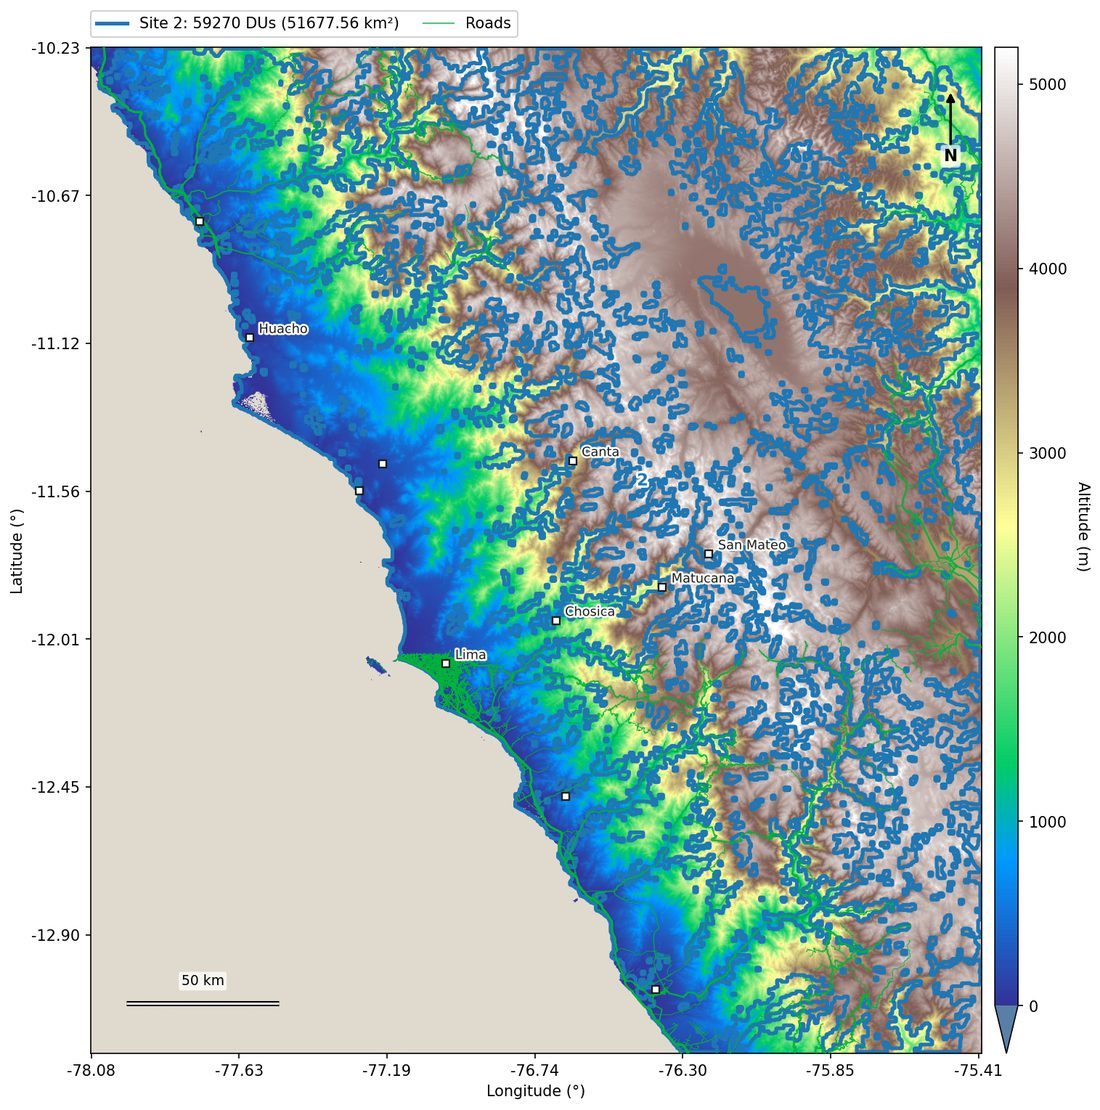

TAMBO over Lima


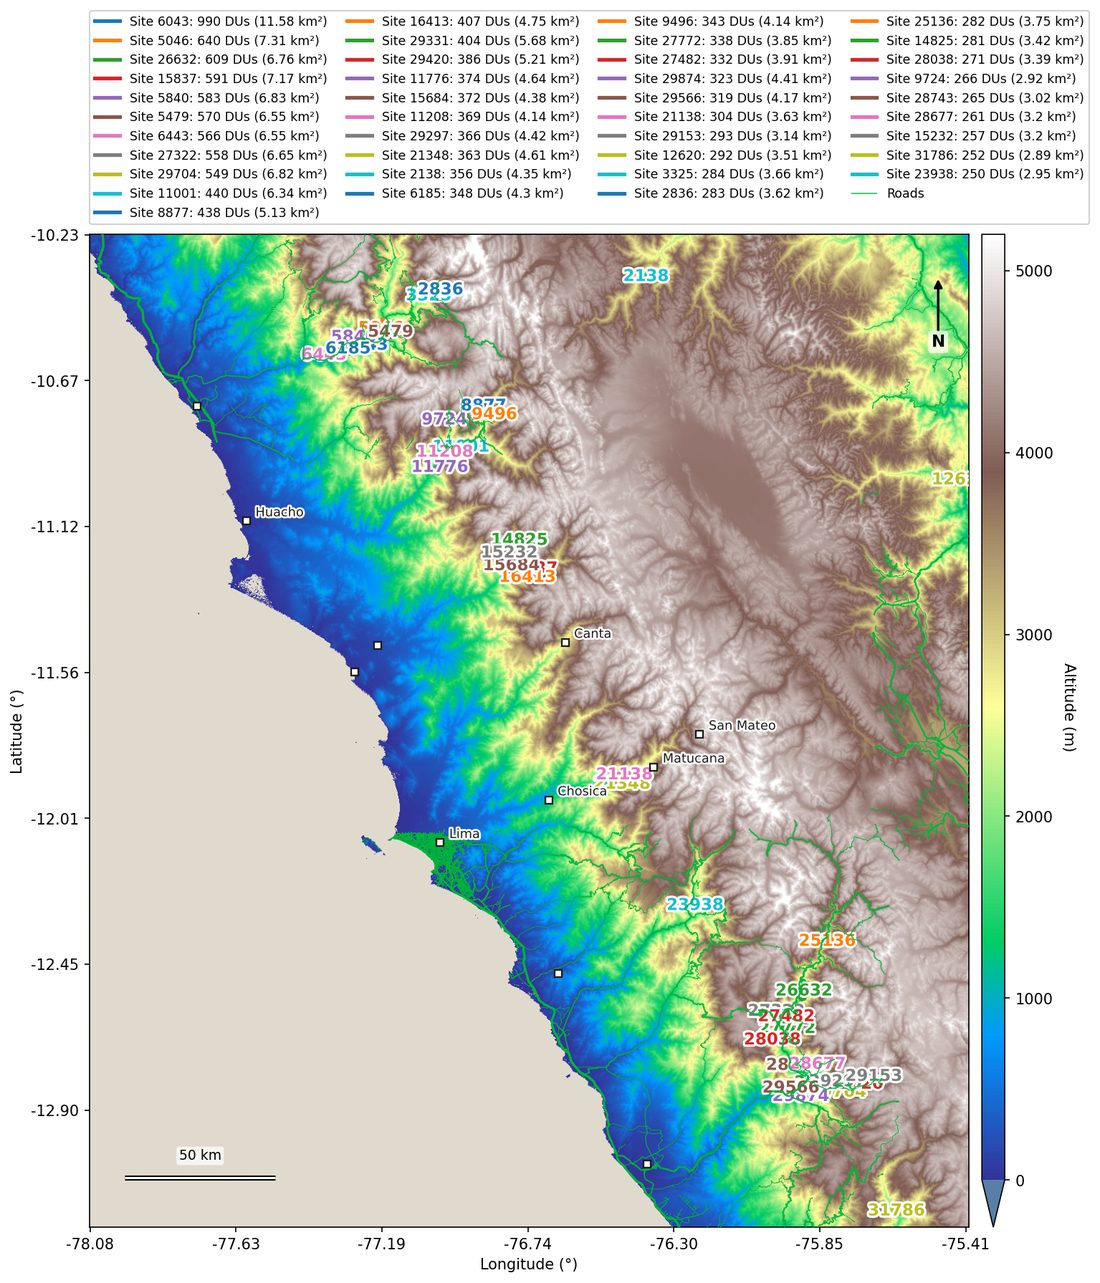

In [8]:
OUT = os.path.abspath(os.path.join("..", "output"))
for label, title in (("grand", "GRAND over Lima"), ("tambo", "TAMBO over Lima")):
    found = sorted(glob.glob(os.path.join(OUT, f"lima_full_{label}",
                                          "oroscope_results*.png")))
    show_figure(found[0] if found else os.path.join(OUT, "missing.png"), caption=title)

GRAND alone


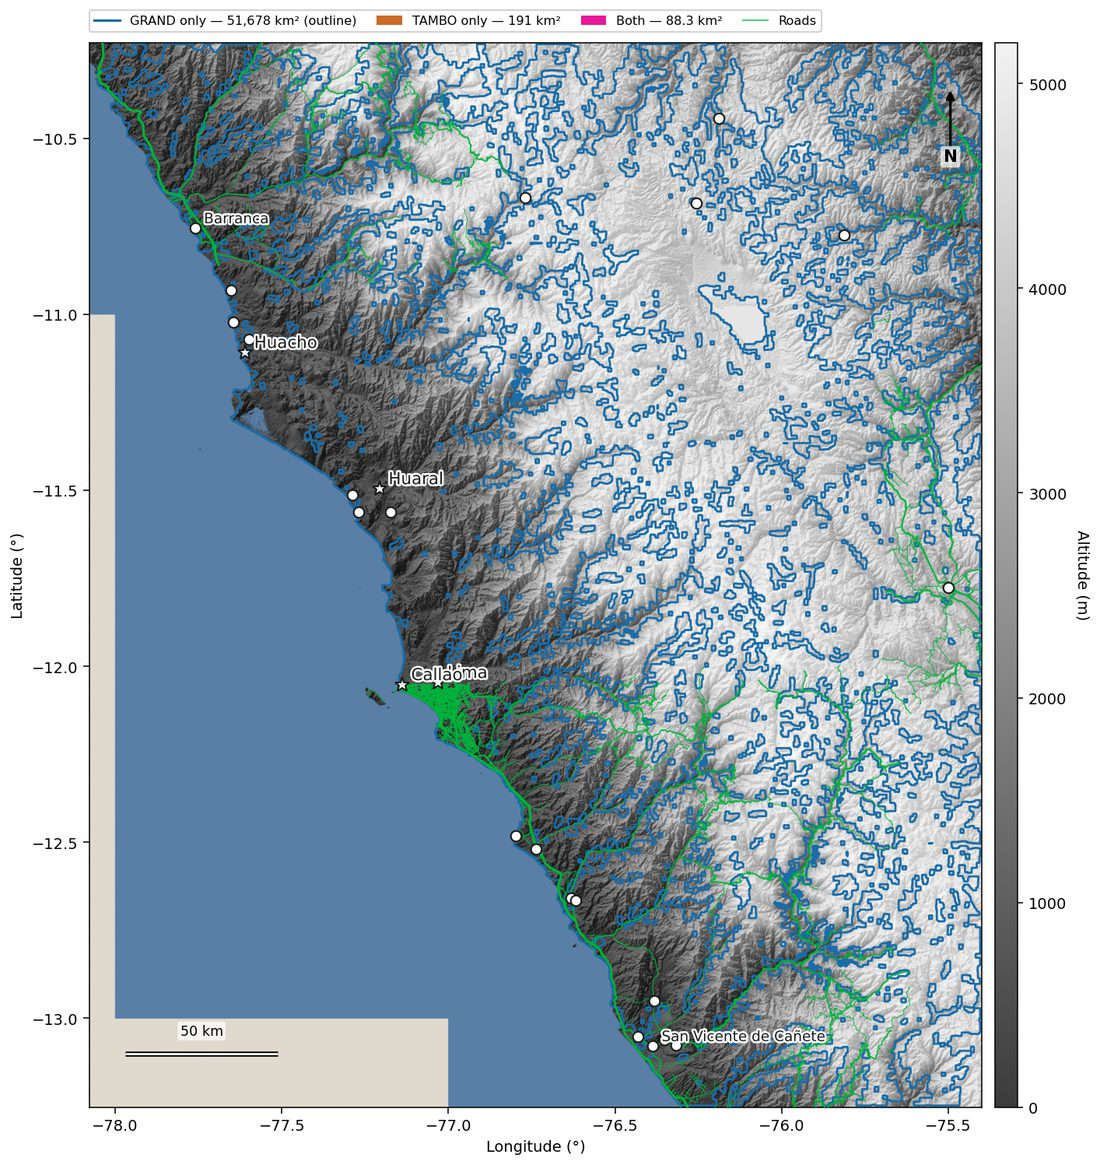

TAMBO alone


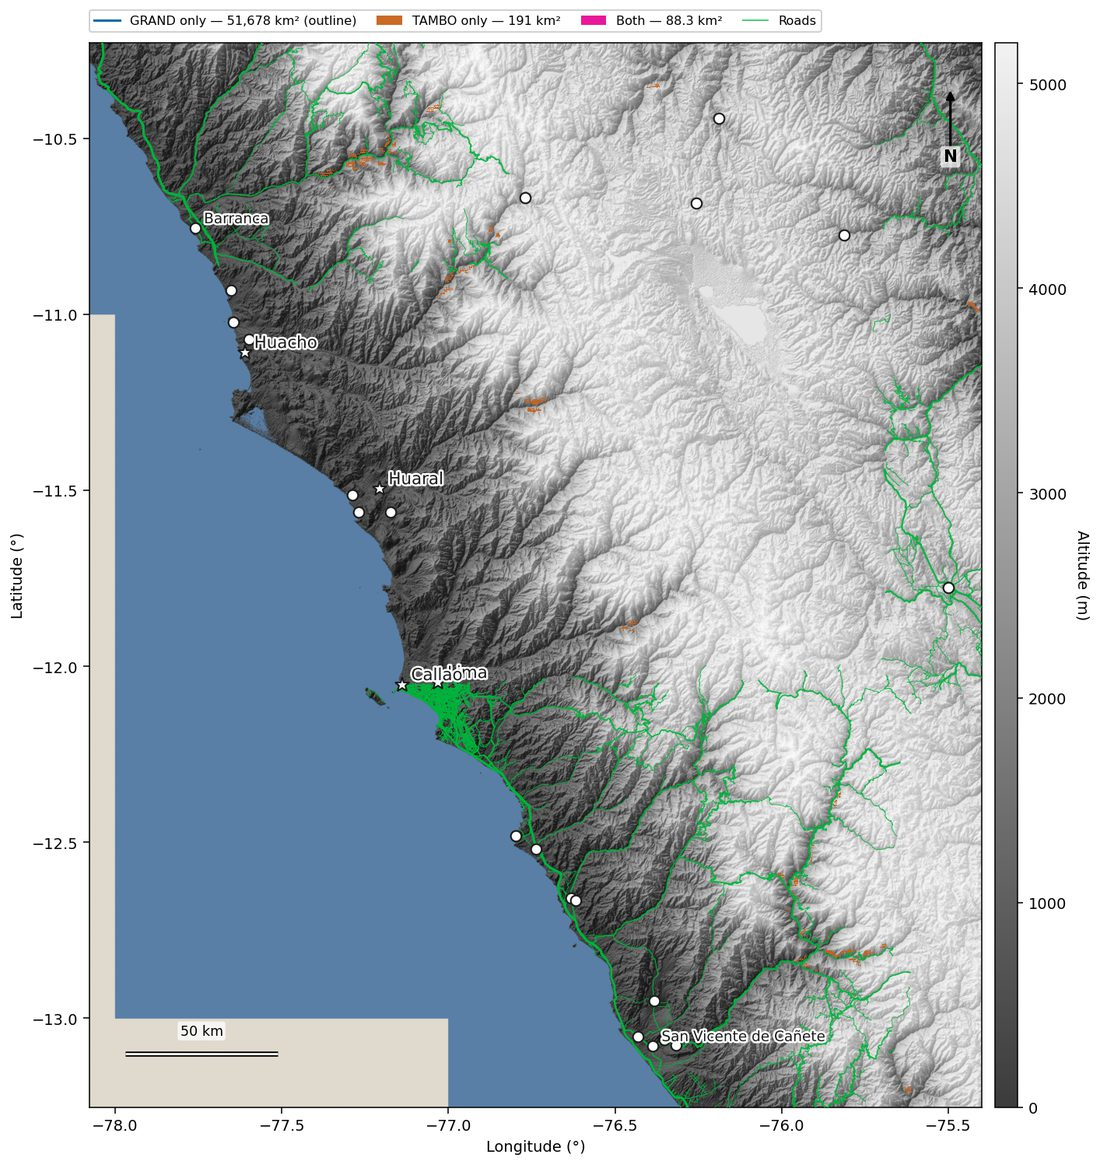

Both — the joint ground


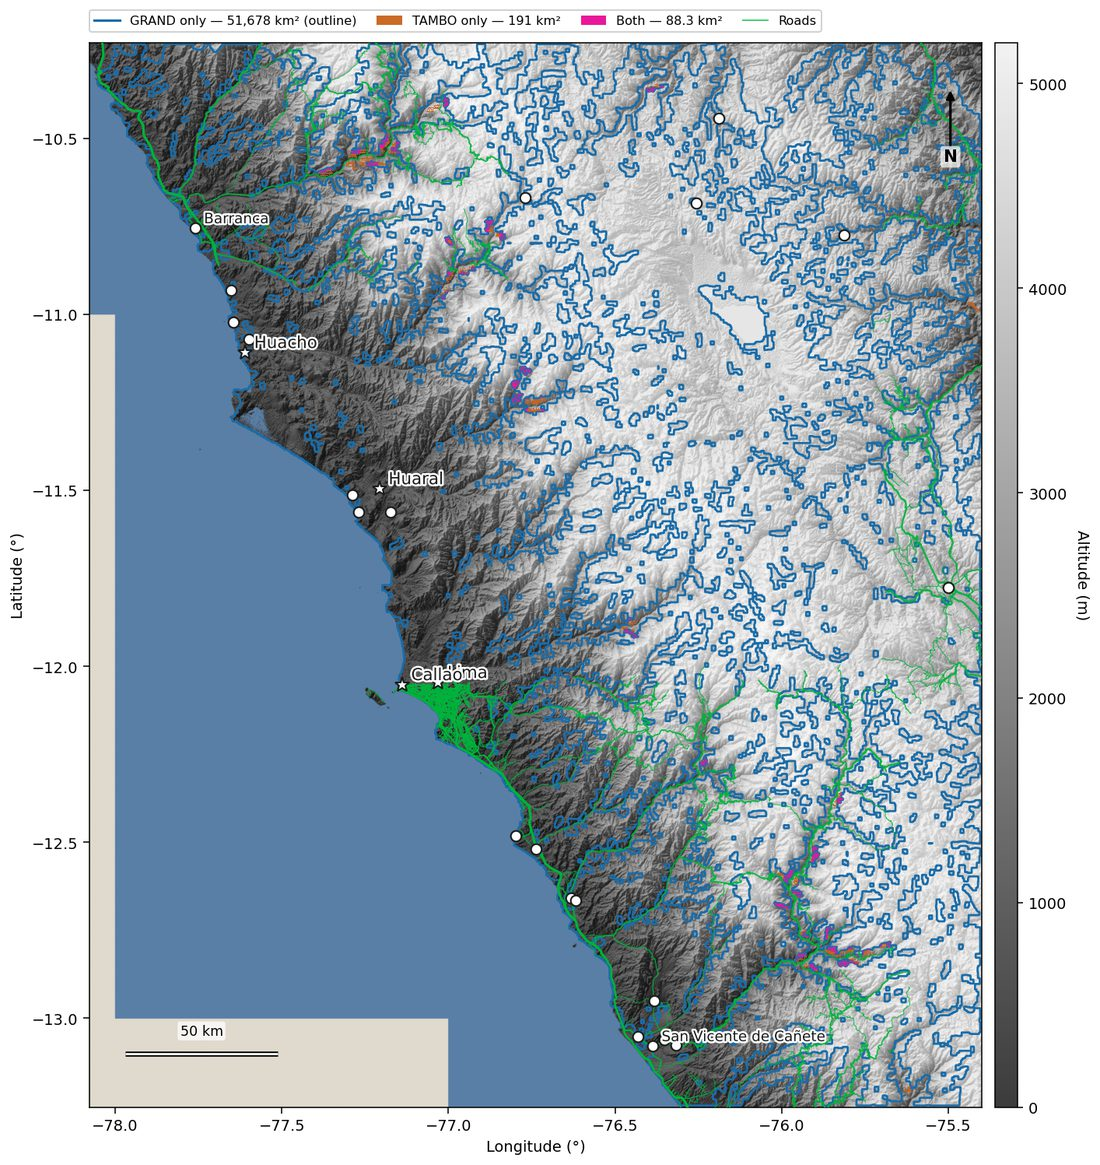

In [9]:
for frame, caption in (("combined_overview_1_grand.png", "GRAND alone"),
                       ("combined_overview_2_tambo.png", "TAMBO alone"),
                       ("combined_overview_3_both.png", "Both — the joint ground")):
    show_figure(os.path.join(OUT, "lima_full_combined", frame), caption=caption)

---

## Zooming in: Cajatambo and the upper Pativilca

Lima's TAMBO sites are not spread evenly. Seventeen of the forty, including the largest,
sit in the north-west corner around Cajatambo — **the same ground the Ancash box reaches
into from the other side**, where the largest joint patch of the whole Ancash run turned
out to be (notebook 10). So this crop does two jobs: it is Lima's densest TAMBO ground,
and running it from the Lima side checks that two independently downloaded, differently
aligned crops of one terrain agree.

8.3 Mpx, so it runs unbiased at `downsample_factor` 1 / `candidate_stride` 1:

```bash
cd src && oroscope-crop ../input/dem/lima_SRTMGL1.tif ../input/dem/cajatambo.tif     --north -10.30 --south -11.10 --west -77.60 --east -76.80
python tools/run_full_dem.py --region cajatambo --max-memory-gb 6.0
```

In [10]:
CROP = os.path.abspath(os.path.join("..", "results", "cajatambo_full"))

print(f"{'':<34}{'sites':>8}{'area km2':>12}{'capacity':>12}")
for label in ("grand", "tambo"):
    for tag, store in ((f"{label.upper()}, Lima department (4/5)", STORES["lima"]),
                       (f"{label.upper()}, Cajatambo crop (1/1)", CROP)):
        path = os.path.join(store, f"{label}_results.json")
        if not os.path.exists(path):
            continue
        with open(path) as f:
            r = json.load(f)["results"]
        sites = r.get("sites") or []
        print(f"{tag:<34}{r['total_sites']:>8,}"
              f"{sum(x.get('area_km2', 0.0) for x in sites):>12,.1f}"
              f"{r['total_capacity']:>12,}")

                                     sites    area km2    capacity
GRAND, Lima department (4/5)             1    51,677.6      59,270
GRAND, Cajatambo crop (1/1)              1     5,541.1       6,424
TAMBO, Lima department (4/5)            40       190.9      15,775
TAMBO, Cajatambo crop (1/1)             97     1,119.2     129,359


**The crop alone finds six times the TAMBO area of the entire Lima department
run, and eight times the detector positions — from 8% of its pixels.** That is not new
terrain; it is the same terrain measured without striding and downsampling, and it is the
291× of notebook 10 arriving independently on different ground.

It also revises something. The joint region's share of TAMBO's mask sat near 44% across
all three department runs, which looked like a constant of the two experiments.

In [11]:
print(f"{'':<28}{'sampling':>10}{'joint km2':>12}{'share of TAMBO':>17}")
for tag, store, samp in (("Arequipa", STORES["arequipa"], "4 / 5"),
                         ("Ancash", STORES["ancash"], "4 / 5"),
                         ("Lima", STORES["lima"], "4 / 5"),
                         ("Huaylas crop", os.path.abspath(os.path.join(
                             "..", "results", "huaylas_full")), "1 / 1"),
                         ("Cajatambo crop", CROP, "1 / 1")):
    path = os.path.join(store, "combined_report.json")
    if not os.path.exists(path):
        continue
    with open(path) as f:
        report = json.load(f)
    o = report["pairwise_overlap"]["GRAND & TAMBO"]
    print(f"{tag:<28}{samp:>10}{report['joint']['area_km2']:>12,.1f}"
          f"{100 * o['fraction_of_TAMBO']:>16.1f}%")

                              sampling   joint km2   share of TAMBO
Arequipa                         4 / 5        50.2            44.9%
Ancash                           4 / 5        75.2            43.0%
Lima                             4 / 5        88.3            46.2%
Huaylas crop                     1 / 1       637.1            74.5%
Cajatambo crop                   1 / 1       805.1            71.9%


**There are two constants, not one, and the strided value is not the real one.**
At 4 / 5 the share is ~44%; at 1 / 1 it is ~73%, on two separate crops. Striding
fragments TAMBO's mask and leaves GRAND's untouched, so what survives a strided run is
the scattered remainder — which overlaps GRAND's contiguous blob less than the intact
mask does.

So the honest statement is that **roughly three quarters of TAMBO-viable ground is also
GRAND-viable**, not four ninths. The *invariance* survives — at fixed sampling the share
barely moves across radically different terrain, which is the real content of the
TAMBO-limited finding — but the number to quote comes from the unbiased runs, and the two
rows must never be mixed.

GRAND over the Cajatambo crop


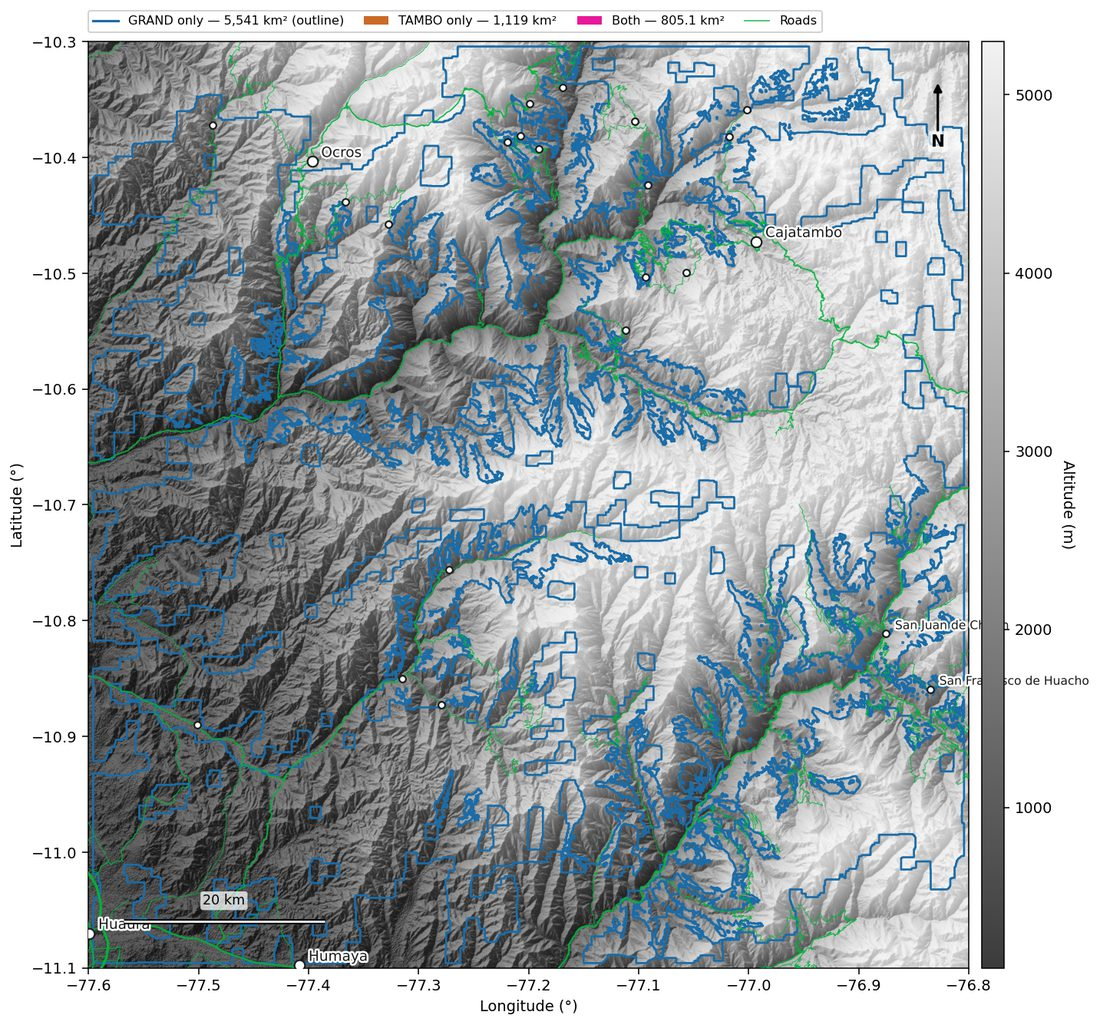

TAMBO at stride 1 — 97 sites


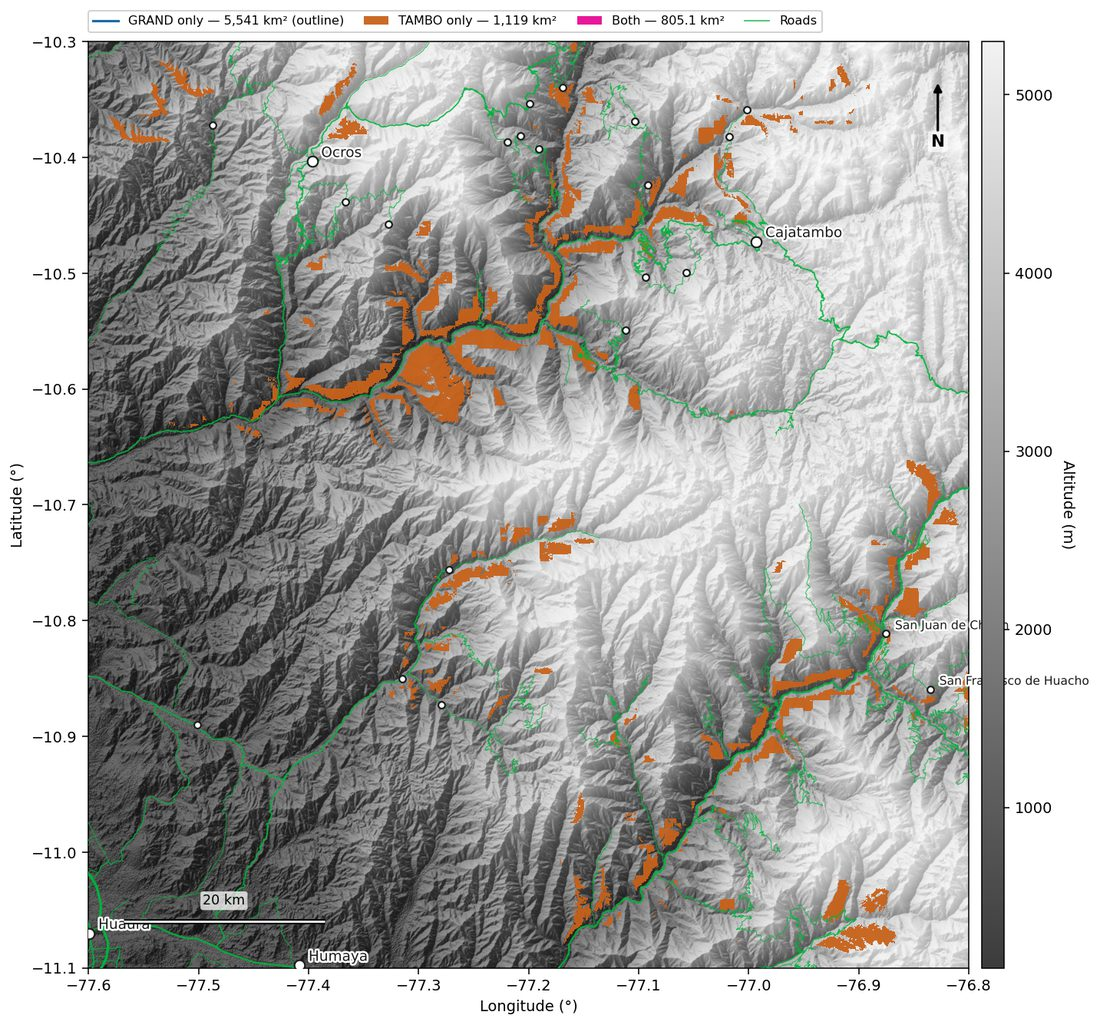

Both — 805 km², 71.9% of TAMBO's mask


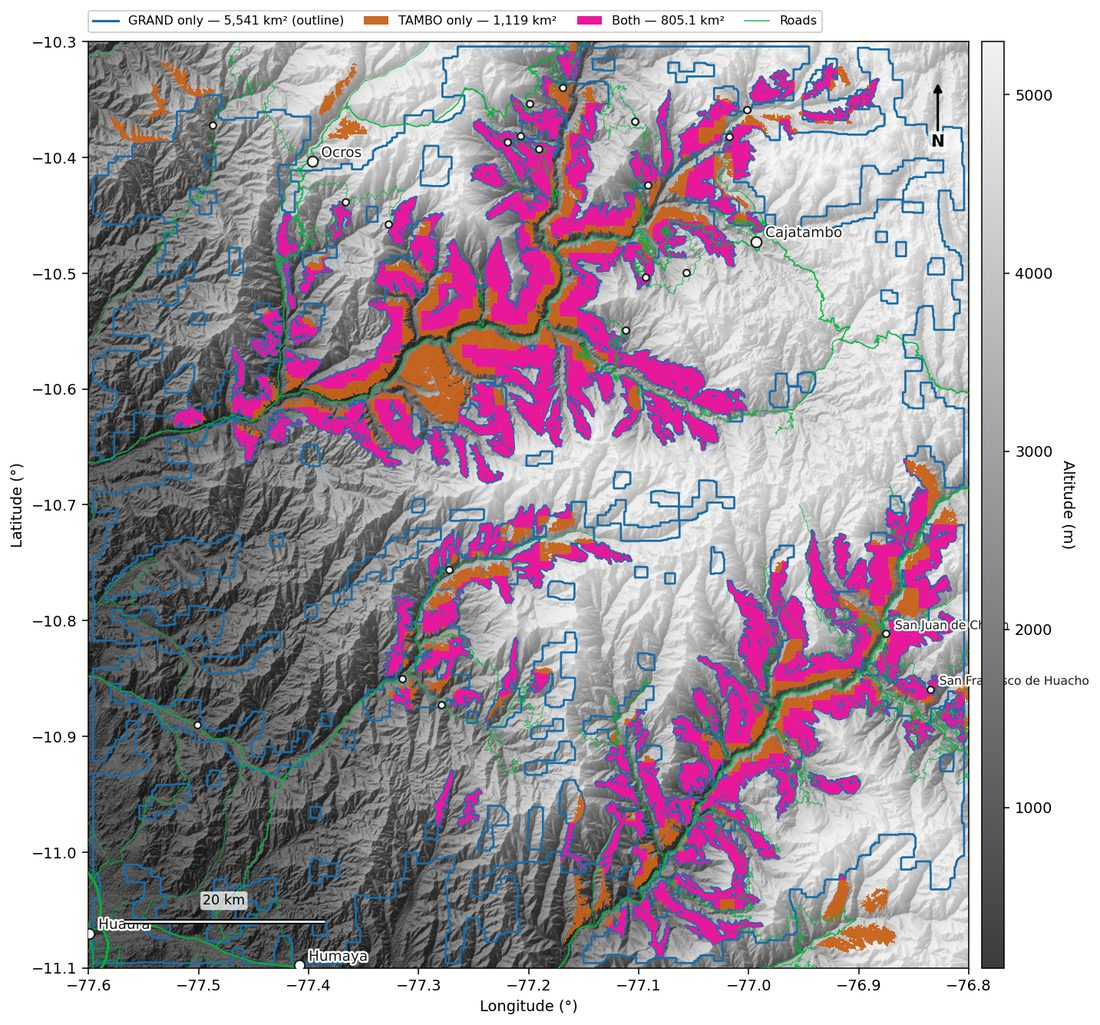

In [12]:
for frame, caption in (
        ("combined_overview_1_grand.png", "GRAND over the Cajatambo crop"),
        ("combined_overview_2_tambo.png", "TAMBO at stride 1 — 97 sites"),
        ("combined_overview_3_both.png", "Both — 805 km², 71.9% of TAMBO's mask")):
    show_figure(os.path.abspath(os.path.join(
        "..", "output", "cajatambo_full_combined", frame)), caption=caption)

---

## Co-locating the two arrays

The searches answer *where each experiment could go*. Deployment asks something else:
**given a site chosen for one, is there enough ground nearby for the other?**

The tempting way to ask is "how much of the joint mask can host GRAND", and it gives the
wrong answer. On the unbiased Cajatambo crop the GRAND-viable ground *inside* the joint
mask is 22,577 fragments of which exactly **one** is large enough for a single 1 km
lattice cell — while 976 km² of perfectly good GRAND ground lies within 20 km. An
optimiser pointed at the intersection would call that site impossible.

**A partner array does not have to stand on the joint mask.** What couples two arrays is
a shared line of sight to the same massif, not a shared footprint — and GRAND's own
targets are 10–40 km away, so an antenna 20 km from a TAMBO strip is watching the same
wall. `ce.colocation_capacity` measures that directly.

In [13]:
from oroscope import combine_experiments as ce

OUTDIRS = {r: os.path.abspath(os.path.join("..", "output", f"{r}_full_grand"))
           for r in ("arequipa", "ancash", "lima")}


def best_tambo_site(region):
    path = os.path.join(STORES[region], "tambo_results.json")
    if not os.path.exists(path):
        return None
    with open(path) as f:
        sites = json.load(f)["results"]["sites"]
    return max(sites, key=lambda s: s["capacity_exact"]) if sites else None


print(f"{'region':<11}{'anchor TAMBO site':>19}{'GRAND within 10 km':>21}"
      f"{'within 20 km':>15}{'within 40 km':>15}")
for region in ("arequipa", "ancash", "lima"):
    site = best_tambo_site(region)
    if not site or not os.path.isdir(OUTDIRS[region]):
        continue
    run = ce.load_run(OUTDIRS[region])
    rows = ce.colocation_capacity(run["mask"], run["world"],
                                  site["center_lat"], site["center_lon"],
                                  radii_km=(10.0, 20.0, 40.0), spacing_km=1.0)
    caps = "".join(f"{r['capacity']:>15,}" for r in rows)
    print(f"{region:<11}{site['capacity_exact']:>13,} units{caps[:21]}{caps[21:]}")

region       anchor TAMBO site   GRAND within 10 km   within 20 km   within 40 km


arequipa             551 units            281          1,261          5,391
ancash               726 units            154            887          3,311


lima                 990 units            149            949          4,183


And the question a proposal actually asks — **how far would the partner array
have to spread?**

In [14]:
WANTED = (100, 1000, 5000)
print(f"{'region':<11}" + "".join(f"{'r for ' + str(w) + ' GRAND':>20}" for w in WANTED))
for region in ("arequipa", "ancash", "lima"):
    site = best_tambo_site(region)
    if not site or not os.path.isdir(OUTDIRS[region]):
        continue
    run = ce.load_run(OUTDIRS[region])
    cells = []
    for want in WANTED:
        r = ce.smallest_radius_for(run["mask"], run["world"], site["center_lat"],
                                   site["center_lon"], want, spacing_km=1.0)
        cells.append(f"{r:.0f} km" if r else "> 80 km")
    print(f"{region:<11}" + "".join(f"{c:>20}" for c in cells))

region          r for 100 GRAND    r for 1000 GRAND    r for 5000 GRAND


arequipa                  10 km               20 km               40 km


ancash                    10 km               30 km               60 km


lima                      10 km               30 km               60 km


**The answer is consistent across all three regions**, which is what makes it
useful: about **10 km for 100 antennas, 20–30 km for 1,000, and 40–60 km for 5,000**.
None of the three is limited by finding GRAND ground near a TAMBO site — the limit is
simply that 1,000 antennas at 1 km spacing need 866 km², and steep country does not offer
that within a few kilometres.

Two caveats, and the first is the one to keep.

**The anchor is each region's largest TAMBO site, and at ``4 / 5`` those capacities are
badly understated** — 551, 726 and 990 units against 6,357 on the unbiased Cajatambo
crop. The *locations* survive striding even where the capacities do not, so the radii
above are sound while the "units" column is a floor.

**The capacity is an anchored lattice**, laid from the region's bounding-box corner
rather than fitted, so it is an estimate for an arbitrarily placed array. Fitting would
do better.

---

## The full explanation of each run

Reproduced in full rather than summarised: the caveats matter as much as the totals, and
they are otherwise sitting in files nobody opens.

In [15]:
def explanation(region, name):
    path = os.path.join(STORES[region], name)
    if not os.path.exists(path):
        print(f"not in the store: {name}")
        return
    with open(path) as f:
        print(f.read())


explanation("lima", "grand_explanation.txt")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/lima_SRTMGL1.tif
  Origin           -10.228472, -78.076806  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 30.3 m E-W
  Layout           distributed search, hex grid, 1.0 km spacing
  Finished         2026-08-16 18:22:56
  Code             commit da54705 on dev (dirty tree)
  DEM checksum     sha256 6c0950eee998af6b…
  Command          tools/run_full_dem.py --region lima --max-memory-gb 6.5

THE HEADLINE
------------
  1 site covering 51,677.6 km², 59,270 detectors against a target of 10,000.

  Largest by capacity: site 2, 51,677.56 km², 59,270 detectors, facing S,
  centred -11.5303, -76.4194 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ----------------------------------------------------------------------
  DEM p

In [16]:
explanation("lima", "tambo_explanation.txt")

 WHAT THIS SEARCH FOUND, AND WHY

THE RUN
-------
  DEM              /home/mbustamante/Research/GRAND/oroscope/input/dem/lima_SRTMGL1.tif
  Origin           -10.228472, -78.076806  (auto-detected from the GeoTIFF tiepoint)
  Resolution       0.00027778°/px  =  30.7 m N-S x 30.3 m E-W
  Layout           distributed search, hex grid, 0.1 km spacing
  Finished         2026-08-16 18:24:17
  Code             commit da54705 on dev (dirty tree)
  DEM checksum     sha256 6c0950eee998af6b…
  Command          tools/run_full_dem.py --region lima --max-memory-gb 6.5

THE HEADLINE
------------
  40 sites covering 190.9 km² between them, 15,775 detectors against a target
  of 5,000.

  Largest by capacity: site 6043, 11.58 km², 990 detectors, facing S, centred
  -10.5660, -77.2358 — paste that into a map.

WHERE THE CANDIDATES WENT
-------------------------
  stage                           |         pixels |   of DEM |  of prev
  ---------------------------------------------------------------------

In [17]:
explanation("lima", "combination_explanation.txt")

 WHERE THESE EXPERIMENTS CAN SHARE GROUND, AND WHY

WHAT EACH BRINGS
----------------
  experiment |     area km² |   sites |  detectors |  in joint
  ----------------------------------------------------------
  GRAND      |     51,677.5 |       1 |     59,270 |      0.2%
  TAMBO      |        190.9 |      40 |     15,775 |     46.2%

  Ground satisfying GRAND and TAMBO at once: 88.3 km². Ground useful to any
  of them: 51,780.2 km². The first is the number that matters for one site,
  one road and one power feed serving two experiments; the second is what the
  programme as a whole could use.

WHAT DECIDES IT
---------------
  A pixel has one slope, one altitude and one aspect, and both experiments
  must accept those same values to stand on it. So co-location is settled by
  whichever of those bands they share least of — before any arrival geometry
  is considered.

  band               |            GRAND |            TAMBO | shared
  -------------------------------------------------

## Where to go next

- **[9. Arequipa, the full DEM](09_arequipa_dem.ipynb)** and
  **[10. Ancash](10_ancash_dem.ipynb)** — the other two thirds of the comparison.
- **[12. Peru, all of it](12_peru_dem.ipynb)** — the whole country at 3 arc-seconds,
  and why a coarse answer has to be read differently.
- **[6. Combining and sensitivity](06_combining_and_sensitivity.ipynb)** — how much of
  any of this survives a change of assumption.

---

*Part of the [Oroscope](https://github.com/mbustama/oroscope) tutorials. Previous: [Ancash](10_ancash_dem.ipynb). Next: [Peru, all of it](12_peru_dem.ipynb). Full API reference: [oroscope docs](https://mbustama.github.io/oroscope/functions.html).*